In [ ]:
!pip install alibi

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectFromModel
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from alibi.explainers import ALE
from alibi.explainers.ale import plot_ale
from sklearn.inspection import PartialDependenceDisplay

df = pd.read_csv("diabetes_012_health_indicators_BRFSS2015.csv")

X = df.drop(columns=["Diabetes_012"])
y = df["Diabetes_012"]

df = df.drop_duplicates()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
selector_model = ExtraTreesClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)

selector_model.fit(X_train, y_train)

#  automatic feature selection
selector = SelectFromModel(selector_model, threshold="median", prefit=True)

X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

print("Pre feature selection shape:", X_train.shape)
print("Post feature selection shape:", X_train_sel.shape)
print("Selected features:", X_train.columns[selector.get_support()])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Pre feature selection shape: (202944, 21)
Post feature selection shape: (202944, 11)
Selected features: Index(['HighBP', 'HighChol', 'BMI', 'Smoker', 'Fruits', 'GenHlth', 'MentHlth',
       'PhysHlth', 'Age', 'Education', 'Income'],
      dtype='object')


In [ ]:
model = ExtraTreesClassifier(
    n_estimators=100,
    max_features=0.5,
    min_samples_leaf=3,
    bootstrap=True,
    oob_score=True,
    random_state=42)

model.fit(X_train_sel, y_train)
print("Accuracy score:", accuracy_score(y_test, model.predict(X_test_sel)))

Accuracy score: 0.847918637653737


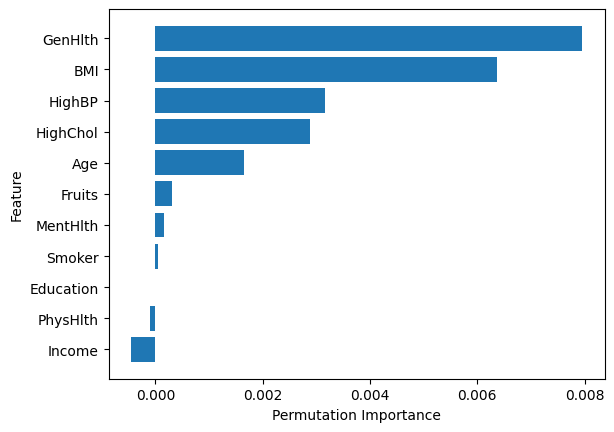

In [ ]:
pi = permutation_importance(model, X_test_sel, y_test)
pi_sorted = pi.importances_mean.argsort()

selected_feature_names = X_test.columns[selector.get_support()]

plt.barh(selected_feature_names[pi_sorted], pi.importances_mean[pi_sorted])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.show()

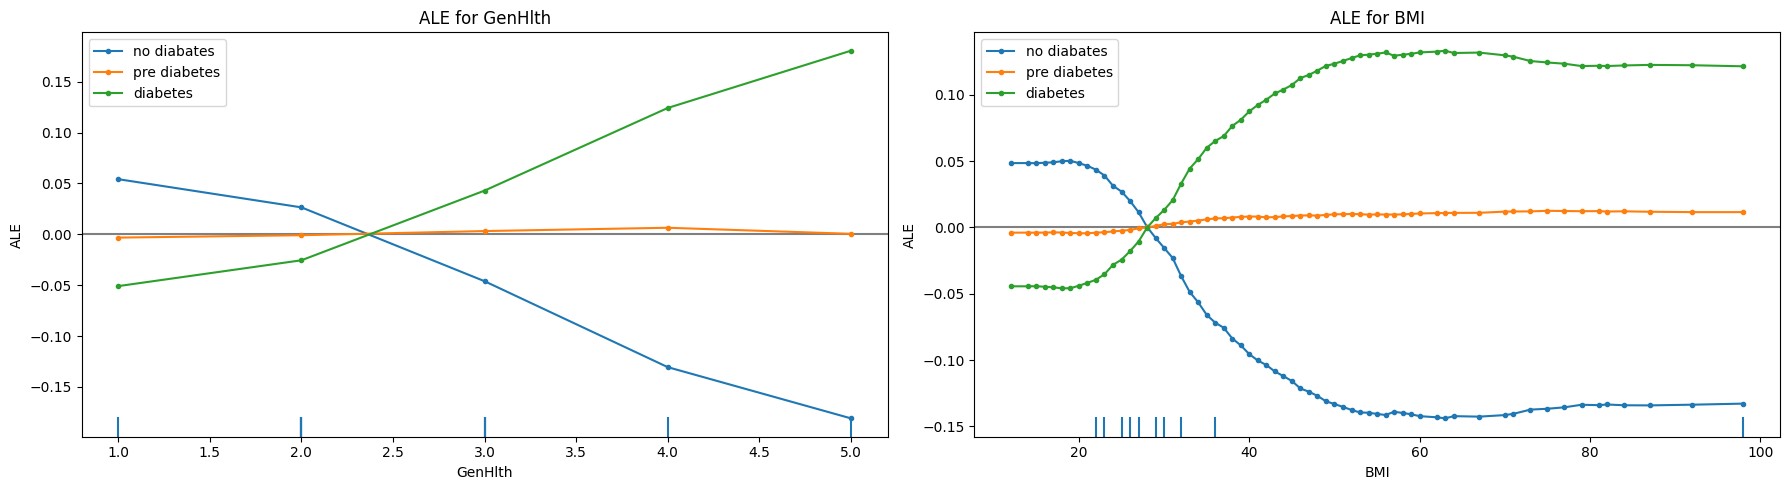

In [ ]:
# Ale for top 2 features
selected_feature_names = X_train.columns[selector.get_support()].tolist()

ale_explainer = ALE(predictor=model.predict_proba, feature_names=selected_feature_names,
                    target_names=['no diabates', 'pre diabetes','diabetes'])

feature_indices = {name: i for i, name in enumerate(selected_feature_names)}
ale_age = ale_explainer.explain(X=X_train_sel, features=[feature_indices['GenHlth']])
ale_chol = ale_explainer.explain(X=X_train_sel, features=[feature_indices['BMI']])

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
plot_ale(ale_age, ax=ax[0])
ax[0].set_title('ALE for GenHlth')
plot_ale(ale_chol, ax=ax[1])
ax[1].set_title('ALE for BMI')

plt.tight_layout()
plt.show()

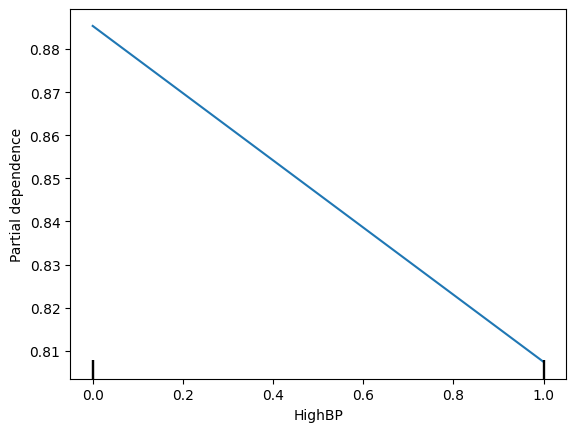

In [ ]:
pdp = PartialDependenceDisplay.from_estimator(
    model,
    X_train_sel,
    features=['HighBP'],
    grid_resolution=20,
    target=0,
    feature_names=selected_feature_names)
pdp

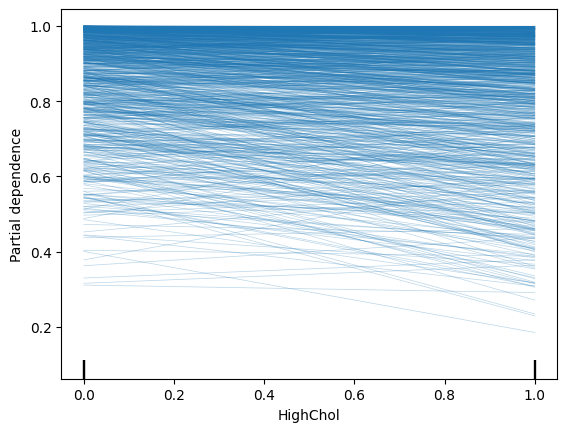

In [ ]:
ice = pdp = PartialDependenceDisplay.from_estimator(
    model,
    X_train_sel,
    features=['HighChol'],
    grid_resolution=20,
    target=0,
    kind='individual',
    feature_names=selected_feature_names)
ice